# Notebook 00 - Sonar intuition and baseline parameters

## What this notebook teaches
- the core sonar story: ping, listen, and turn delay into range
- why sound speed in water sets the timing scale for every later chapter
- how the baseline scene gives us a concrete duty cycle, delay, and sample delay

## Where we are in the story
An active sonar measures range by timing how long sound takes to travel through water, reflect from a target, and come back. This notebook does one job: set up a clean baseline scene and show how the same echo delay becomes a time delay, then a sample delay, then a range in metres. Later notebooks build on that foundation with sweeps, correlation-based matched filtering, and Doppler maps.

In [1]:
from helpers import BASELINE_SCENE

sound_speed_m_s = BASELINE_SCENE["sound_speed_m_s"]
ping_width_s = BASELINE_SCENE["ping_width_s"]
inter_ping_interval_s = BASELINE_SCENE["inter_ping_interval_s"]
sample_rate_hz = BASELINE_SCENE["sample_rate_hz"]
target_range_m = BASELINE_SCENE["target_range_m"]

print(f"Sound speed: {sound_speed_m_s:.0f} m/s")
print(f"Ping width: {ping_width_s:.3f} s")
print(f"Inter-ping interval: {inter_ping_interval_s:.3f} s")
print(f"Sample rate: {sample_rate_hz:.0f} Hz")
print(f"Target range: {target_range_m:.1f} m")

Sound speed: 1500 m/s
Ping width: 0.050 s
Inter-ping interval: 0.200 s
Sample rate: 10000 Hz
Target range: 75.0 m


## Baseline values and governing equations
The story starts with two equations because they tell us how a sonar converts timing into meaning:

$D = \tau / T$

for the transmit duty cycle, and

$R = c \cdot \tau_{delay} / 2$

for range from round-trip delay. Here $\tau$ is the ping width, $T$ is the time from one ping start to the next, $c$ is sound speed in water, and $\tau_{delay}$ is the echo delay. The rest of the notebook is simply showing those two equations with real numbers.

In [2]:
duty_cycle_value = ping_width_s / inter_ping_interval_s
listen_window_s = inter_ping_interval_s - ping_width_s

print(f"Duty cycle D = tau / T = {ping_width_s:.3f} / {inter_ping_interval_s:.3f} = {duty_cycle_value:.2f}")
print(f"Quiet listening time each ping: {listen_window_s:.3f} s")

Duty cycle D = tau / T = 0.050 / 0.200 = 0.25
Quiet listening time each ping: 0.150 s


In [3]:
round_trip_delay_s = 2.0 * target_range_m / sound_speed_m_s
delay_samples = round(round_trip_delay_s * sample_rate_hz)
recovered_range_m = sound_speed_m_s * round_trip_delay_s / 2.0

print(f"Round-trip delay = 2R/c = 2 * {target_range_m:.1f} / {sound_speed_m_s:.0f} = {round_trip_delay_s:.3f} s")
print(f"Delay in samples = {round_trip_delay_s:.3f} * {sample_rate_hz:.0f} = {delay_samples} samples")
print(f"Recovered range = c * tau_delay / 2 = {recovered_range_m:.1f} m")

Round-trip delay = 2R/c = 2 * 75.0 / 1500 = 0.100 s
Delay in samples = 0.100 * 10000 = 1000 samples
Recovered range = c * tau_delay / 2 = 75.0 m


## Same calculation, reusable form
The same arithmetic now appears again through the helpers in this folder. Nothing new is being introduced; this is simply the packaged version of the exact same calculation, which is why later notebooks can reuse it without rewriting the math.

Helper duty cycle: 0.25
Helper delay samples: 1000
Helper recovered range: 75.0 m


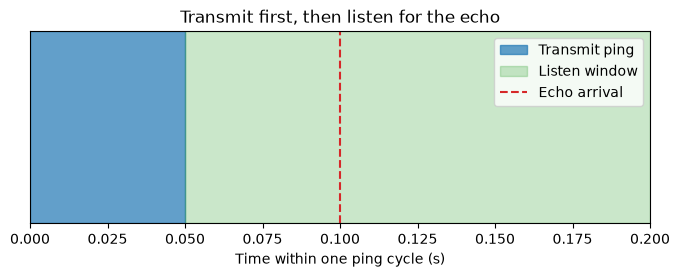

In [4]:
import matplotlib.pyplot as plt

from helpers import delay_samples_for_range, duty_cycle, range_from_delay

helper_duty_cycle = duty_cycle(ping_width_s, inter_ping_interval_s)
helper_delay_samples = delay_samples_for_range(sound_speed_m_s, target_range_m, sample_rate_hz)
helper_range_m = range_from_delay(sound_speed_m_s, round_trip_delay_s)

print(f"Helper duty cycle: {helper_duty_cycle:.2f}")
print(f"Helper delay samples: {helper_delay_samples}")
print(f"Helper recovered range: {helper_range_m:.1f} m")

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.axvspan(0.0, ping_width_s, color="tab:blue", alpha=0.7, label="Transmit ping")
ax.axvspan(ping_width_s, inter_ping_interval_s, color="tab:green", alpha=0.25, label="Listen window")
ax.axvline(round_trip_delay_s, color="tab:red", linestyle="--", label="Echo arrival")
ax.set_xlim(0.0, inter_ping_interval_s)
ax.set_yticks([])
ax.set_xlabel("Time within one ping cycle (s)")
ax.set_title("Transmit first, then listen for the echo")
ax.legend(loc="upper right")
plt.show()

## Checkpoint
- Why does the range equation divide by 2 instead of 1?
- What happens to the listen window if the ping width grows while the inter-ping interval stays fixed?
- Why is 0.1 s a reasonable round-trip delay in water but not in radar?

## Common mistake
Confusing one-way travel time with round-trip delay. The measured echo delay includes the trip out to the target and the trip back.

## Stretch
Keep the same sample rate and sound speed, but move the target to 120 m. Compute the new delay in seconds and samples.

## Summary
Active sonar works by transmitting briefly and listening for a much longer period. The whole point of this notebook is to show how that rhythm turns a physical distance into a delay, a delay into samples, and samples back into range. That idea is the foundation for the rest of the course.

## Answers, corrections, and stretch

### Checkpoint answers

1. **Why does the range equation divide by 2 instead of 1?**
   Because the measured echo delay includes the trip from the sonar to the target and the trip back again. The sound covers the distance twice, so the round-trip delay is twice the one-way travel time. The direct answer is that range is one-half of the total path length written in time: $R = c\,\tau_{delay}/2$.

2. **What happens to the listen window if the ping width grows while the inter-ping interval stays fixed?**
   The listen window gets shorter. If the sonar spends more time transmitting, there is less quiet time left in the same cycle for listening to the echo. That matters because the receiver needs time to hear the return after the ping ends.

3. **Why is 0.1 s a reasonable round-trip delay in water but not in radar?**
   Because sound in water travels much more slowly than electromagnetic waves do in air or space. A target at 75 m gives a 0.1 s delay in this sonar scene, which is easy to see and work with. In radar, the same distance would produce a much shorter delay, so the timing scale would be completely different.

### Common mistakes and the correct understanding

- **Mistake: treating the range equation as a one-way distance formula.**
  This is incorrect because the echo delay measures a round trip. The corrected view is that the sonar measures the whole out-and-back journey, then divides by two to recover the one-way range.

- **Mistake: thinking the duty cycle is just a bookkeeping detail.**
  It is not. The duty cycle determines how much of each ping cycle is available for transmission versus listening, so it affects both the energy sent into the water and the time left to hear the return.

- **Mistake: thinking the sample delay is separate from the physical delay.**
  It is the same delay written in digital form. The physics gives you the time; the sampling rate tells you how that time appears in samples.

### Stretch example

Run this snippet and compare the printed delay to the 75 m baseline in the notebook.

The point of the stretch is to make the same relationship feel automatic: once you know the range, you can predict the delay, and once you know the delay, you can predict the range.

### Closing the loop

Notebook 00 starts with a simple idea: active sonar sends a ping, waits for the echo, and uses the delay to recover range. The whole notebook is really just that idea written three ways: in words, in equations, and in code. Once that feels natural, the later notebooks can build on it without changing the underlying story.


In [ ]:
sound_speed_m_s = 1500.0
sample_rate_hz = 10_000.0
new_range_m = 120.0

new_delay_s = 2.0 * new_range_m / sound_speed_m_s
new_delay_samples = round(new_delay_s * sample_rate_hz)

print(f"New range: {new_range_m:.1f} m")
print(f"Round-trip delay: {new_delay_s:.3f} s")
print(f"Delay in samples: {new_delay_samples} samples")

The output should show a longer delay than the 75 m baseline because the target is farther away, and the number of samples should increase in the same proportion. That is the important pattern: range and delay scale together, and the sampling rate just writes that same delay in digital form.